## Feature engineering

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%pip install --upgrade pyarrow
import pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Load data
df = pd.read_parquet("../data/processed/transformed_data.parquet")

In [6]:
state_cols = ['Estado General MB', 'Estado General B', 'Estado General R', 'Estado General M']

state_sums = df[state_cols].sum(axis=1)
print(f"Rows with state sum <= 95%: {(state_sums <= 95).sum()}")

print(f"Rows with exactly 100% in 'B': {(df['Estado General B'] == 100).sum()}")

Rows with state sum <= 95%: 2859
Rows with exactly 100% in 'B': 4159


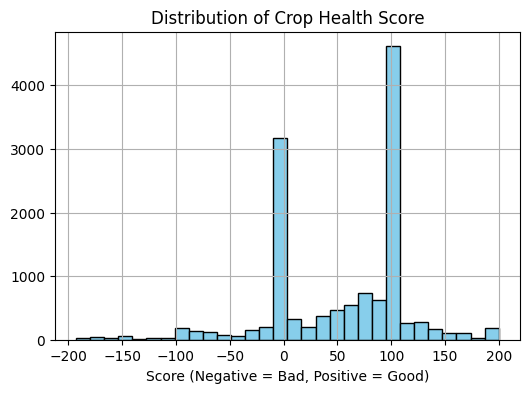

In [8]:
# ## 2. Defining a Single Health Score

df['Score'] = (
    (-2 * df['Estado General M']) + 
    (-1 * df['Estado General R']) + 
    (1  * df['Estado General B']) + 
    (2  * df['Estado General MB'])
)

df['Score'].hist(bins=30, figsize=(6,4), color='skyblue', edgecolor='black')
plt.title("Distribution of Crop Health Score")
plt.xlabel("Score (Negative = Bad, Positive = Good)")
plt.show()


In [12]:
df['Estado_Malo'] = np.select([df['Score'] > 0], [0], default=1).astype(float)

print("Target distribution (0 = Good, 1 = Bad):")
print(df['Estado_Malo'].value_counts(dropna=False))


Target distribution (0 = Good, 1 = Bad):
Estado_Malo
0.0    9064
1.0    4253
Name: count, dtype: int64


In [13]:
# ## 3. Phenological Dominance & Scope
feno_cols = ['Estadio Fenológico E', 'Estadio Fenológico C', 'Estadio Fenológico F', 'Estadio Fenológico L', 'Estadio Fenológico M']
df[feno_cols] = df[feno_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Extract the name of the column with the highest percentage for each row
df['estado_fenologico_dominante'] = df[feno_cols].idxmax(axis=1)

print("Dominant phenological stages:")
print(df['estado_fenologico_dominante'].value_counts())

# Filter scope
df_trigo = df[df["CULTIVO"] == "TRIGO"].copy()
print(f"\nFinal shape for TRIGO modeling: {df_trigo.shape}")

Dominant phenological stages:
estado_fenologico_dominante
Estadio Fenológico M    3471
Estadio Fenológico C    3460
Estadio Fenológico E    3281
Estadio Fenológico L    2120
Estadio Fenológico F     985
Name: count, dtype: int64

Final shape for TRIGO modeling: (3767, 47)
